# Stage C3 – Tariff Matching & Recommendation

This notebook:
- Loads cleaned smart meter usage data (30-minute intervals)
- Loads scraped Electric Ireland tariff data
- Estimates annual cost of electricity for each plan
- Ranks plans by cheapest estimated cost
- Produces tables and plots for reporting

Inputs:
- data/clean/clean_{LABEL}_30min.csv
- data/tariffs/clean/electric_ireland_all_plans.csv

Outputs:
- reports/tables/tariff_match_results_{LABEL}.csv
- reports/figures/top_plans_{LABEL}.png


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
warnings.filterwarnings("default")

In [4]:
# ===== USER CONFIG =====

LABEL = "2024"   # <-- CHANGE THIS to match your C2 run label

# Input files
USAGE_FILE = Path(f"../data/clean/clean_{LABEL}_30min.csv")
TARIFF_FILE = Path("../data/tariffs/clean/electric_ireland_all_plans.csv")

# Outputs
OUT_TABLE = Path(f"../reports/tables/tariff_match_results_{LABEL}.csv")
OUT_FIGURES = Path("../reports/figures")

OUT_FIGURES.mkdir(parents=True, exist_ok=True)

In [5]:
# Load cleaned usage data
usage = pd.read_csv(
    USAGE_FILE,
    parse_dates=["timestamp_utc", "timestamp_local"],
    index_col="timestamp_utc"
)

# Load tariff data
tariffs = pd.read_csv(TARIFF_FILE)

print("Usage shape:", usage.shape)
print("Tariffs shape:", tariffs.shape)

usage.head(), tariffs.head()

Usage shape: (17568, 7)
Tariffs shape: (9, 12)


(                              kWh            timestamp_local  flag_negative        date    month     dow  is_weekend
 timestamp_utc                                                                                                       
 2024-01-01 00:00:00+00:00  0.1370  2024-01-01 00:00:00+00:00          False  2024-01-01  2024-01  Monday       False
 2024-01-01 00:30:00+00:00  0.1450  2024-01-01 00:30:00+00:00          False  2024-01-01  2024-01  Monday       False
 2024-01-01 01:00:00+00:00  0.9865  2024-01-01 01:00:00+00:00          False  2024-01-01  2024-01  Monday       False
 2024-01-01 01:30:00+00:00  0.5050  2024-01-01 01:30:00+00:00          False  2024-01-01  2024-01  Monday       False
 2024-01-01 02:00:00+00:00  0.0820  2024-01-01 02:00:00+00:00          False  2024-01-01  2024-01  Monday       False,
            supplier                      plan_name meter_type structure  unit_rate_24h_eur_kwh  unit_rate_day_eur_kwh  \
 0  Electric Ireland                EnergySaver 20%

In [6]:
# Basic checks
assert usage.index.is_monotonic_increasing
assert "kWh" in usage.columns
assert "timestamp_local" in usage.columns

total_kwh = usage["kWh"].sum()
negatives = (usage["kWh"] < 0).sum()

print(f"Total annual consumption: {total_kwh:.2f} kWh")
print(f"Negative readings flagged: {negatives}")

Total annual consumption: 5066.44 kWh
Negative readings flagged: 0


In [7]:
# ===== TARIFF TIME WINDOWS (Europe/Dublin) =====

TARIFF_WINDOWS = {
    "day_night": {
        "night_start": 23,   # 23:00
        "night_end": 8       # 08:00
    },
    "three_period": {
        "night_start": 23,
        "night_end": 8,
        "peak_start": 17,    # 17:00
        "peak_end": 19       # 19:00
    }
}

In [8]:
def assign_period(ts_local, structure):
    """
    Assign tariff period based on local timestamp and plan structure.
    Returns one of: 'day', 'night', 'peak'
    """
    hour = ts_local.hour

    if structure == "24h":
        return "day"

    if structure == "DayNight":
        ns = TARIFF_WINDOWS["day_night"]["night_start"]
        ne = TARIFF_WINDOWS["day_night"]["night_end"]
        return "night" if (hour >= ns or hour < ne) else "day"

    if structure == "3-Period":
        ns = TARIFF_WINDOWS["three_period"]["night_start"]
        ne = TARIFF_WINDOWS["three_period"]["night_end"]
        ps = TARIFF_WINDOWS["three_period"]["peak_start"]
        pe = TARIFF_WINDOWS["three_period"]["peak_end"]

        if hour >= ns or hour < ne:
            return "night"
        if ps <= hour < pe:
            return "peak"
        return "day"

    raise ValueError(f"Unknown structure: {structure}")

In [12]:
def compute_usage_by_period(usage_df, structure):
    df = usage_df.copy()
    df["period"] = df["timestamp_local"].apply(assign_period, structure=structure)

    grouped = df.groupby("period")["kWh"].sum()

    # Ensure all expected periods exist (pandas-safe)
    grouped = grouped.reindex(["day", "night", "peak"], fill_value=0.0)

    return grouped


In [13]:
def cost_plan(usage_df, tariff_row):
    structure = tariff_row["structure"]

    usage_split = compute_usage_by_period(usage_df, structure)
    total_kwh_check = usage_split.sum()

    # Sanity check
    if not np.isclose(total_kwh_check, usage_df["kWh"].sum(), rtol=1e-4):
        warnings.warn("Usage split does not sum to total kWh")

    cost = 0.0

    try:
        if structure == "24h":
            cost = usage_split["day"] * tariff_row["unit_rate_24h_eur_kwh"]

        elif structure == "DayNight":
            cost = (
                usage_split["day"] * tariff_row["unit_rate_day_eur_kwh"] +
                usage_split["night"] * tariff_row["unit_rate_night_eur_kwh"]
            )

        elif structure == "3-Period":
            cost = (
                usage_split["day"] * tariff_row["unit_rate_day_eur_kwh"] +
                usage_split["night"] * tariff_row["unit_rate_night_eur_kwh"] +
                usage_split["peak"] * tariff_row["unit_rate_peak_eur_kwh"]
            )

        else:
            raise ValueError("Unsupported structure")

    except KeyError as e:
        warnings.warn(f"Missing rate for plan {tariff_row['plan_name']}: {e}")
        return np.nan

    return cost

In [14]:
results = []

for _, row in tariffs.iterrows():
    est_cost = cost_plan(usage, row)

    results.append({
        "supplier": row["supplier"],
        "plan_name": row["plan_name"],
        "meter_type": row["meter_type"],
        "structure": row["structure"],
        "estimated_cost_eur": est_cost,
        "scraped_estimated_bill_eur": row.get("estimated_annual_bill_eur", np.nan)
    })

results_df = pd.DataFrame(results).sort_values("estimated_cost_eur")

results_df

,supplier,plan_name,meter_type,structure,estimated_cost_eur,scraped_estimated_bill_eur
4,Electric Ireland,Home Electric + SST Saver 24%,Smart,3-Period,1224.746774,1255.0
8,Electric Ireland,Home Electric SST Saver 24%,Smart,3-Period,1224.746774,1255.0
1,Electric Ireland,EnergySaver NightSaver 20%,DayNight,DayNight,1266.157184,1354.0
6,Electric Ireland,Home Electric + Night Boost 16%,Smart,DayNight,1302.271966,1370.0
5,Electric Ireland,Home Electric + Saver 24%,Smart,24h,1310.180996,1356.0
0,Electric Ireland,EnergySaver 20%,Standard,24h,1408.469903,1437.0
3,Electric Ireland,Green Electricity NightSaver,DayNight,DayNight,1506.091892,1545.0
7,Electric Ireland,Home Electric+ Weekender Saver 16%,Smart,24h,1589.848401,1471.0
2,Electric Ireland,Green Electricity,Standard,24h,1671.924705,1656.0


In [15]:
results_df.to_csv(OUT_TABLE, index=False)
OUT_TABLE

WindowsPath('../reports/tables/tariff_match_results_2024.csv')

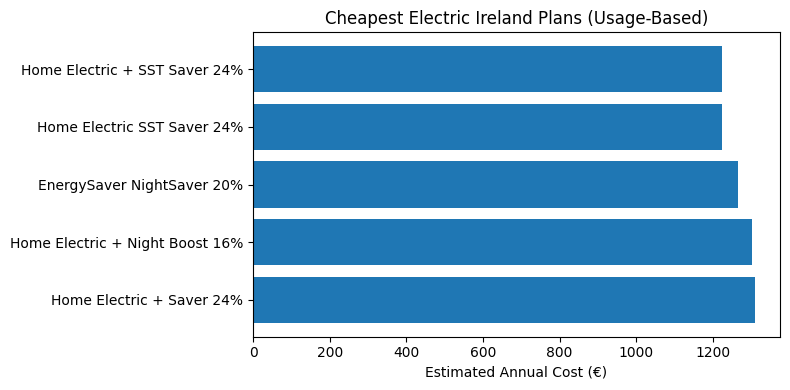

In [16]:
TOP_N = 5

plt.figure(figsize=(8, 4))
plt.barh(
    results_df.head(TOP_N)["plan_name"],
    results_df.head(TOP_N)["estimated_cost_eur"]
)
plt.xlabel("Estimated Annual Cost (€)")
plt.title("Cheapest Electric Ireland Plans (Usage-Based)")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(OUT_FIGURES / f"top_plans_{LABEL}.png", dpi=150)
plt.show()

In [17]:
def cost_breakdown(usage_df, tariff_row):
    structure = tariff_row["structure"]
    usage_split = compute_usage_by_period(usage_df, structure)

    breakdown = {}

    if structure == "24h":
        breakdown["day"] = usage_split["day"] * tariff_row["unit_rate_24h_eur_kwh"]

    elif structure == "DayNight":
        breakdown["day"] = usage_split["day"] * tariff_row["unit_rate_day_eur_kwh"]
        breakdown["night"] = usage_split["night"] * tariff_row["unit_rate_night_eur_kwh"]

    elif structure == "3-Period":
        breakdown["day"] = usage_split["day"] * tariff_row["unit_rate_day_eur_kwh"]
        breakdown["night"] = usage_split["night"] * tariff_row["unit_rate_night_eur_kwh"]
        breakdown["peak"] = usage_split["peak"] * tariff_row["unit_rate_peak_eur_kwh"]

    return breakdown


best = results_df.iloc[0]
second = results_df.iloc[1]

best_row = tariffs[tariffs["plan_name"] == best["plan_name"]].iloc[0]
second_row = tariffs[tariffs["plan_name"] == second["plan_name"]].iloc[0]

bd_best = cost_breakdown(usage, best_row)
bd_second = cost_breakdown(usage, second_row)

pd.DataFrame([bd_best, bd_second], index=["Best", "Second Best"])

,day,night,peak
Best,832.752226,233.612931,158.381617
Second Best,832.752226,233.612931,158.381617


In [18]:
def is_free_period(ts_local, plan_name):
    # Example stub for future extension
    if "Weekender" in plan_name:
        if ts_local.weekday() >= 5 and 8 <= ts_local.hour < 23:
            return True
    return False